
<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day2_pose_estimation/Day2_MouseObjectInteraction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐭 Mouse–Object Interaction Analysis
## Day 2 Afternoon: From Raw Tracking to Behavioral Quantification

---

### Learning Objectives
By the end of this session you will be able to:

1. **Load and quality-filter** DeepLabCut pose estimation data
2. **Extract locomotor features**: speed, movement direction, distance from arena center
3. **Detect interactions** between the mouse and arena objects using proximity thresholds
4. **Identify interaction bouts**: contiguous periods of close proximity
5. **Quantify and compare** exploration across three objects (visit count, total duration)

---

### Dataset overview

| File | Description |
|------|-------------|
| `dlc_tracking.csv` | DeepLabCut output — nose, head, spine1, spine2 positions + likelihood |
| `object_centers.csv` | Pre-detected object positions (from Day 2 morning session) |

**Recording specs**: Top-down video, ~30 fps, open-field arena with 3 objects  
**Tracked keypoints**: nose · head · spine1 · spine2

---
> **Coordinate system**: Origin `(0,0)` at top-left corner of frame.  
> `x` increases rightward, `y` increases downward (same as DeepLabCut output).


## 🔧 Setup

In [2]:
# Install any extra packages if needed (Colab already has most)
# !pip install seaborn scipy --quiet  # uncomment if needed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.ndimage import uniform_filter1d
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

print("✓ All packages imported successfully!")


✓ All packages imported successfully!


### 1.Load your real data (run this block when you have actual files)



In [71]:
FPS = 20
url_path = ''  # from morning session

!curl -O https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/object_recg/extracted_trajectory.csv
raw = pd.read_csv('extracted_trajectory.csv', header=[0, 1, 2], index_col=0)
raw.columns = ['_'.join(col[1:]).strip() for col in raw.columns]
raw.index.name = 'frame'
dlc_raw = raw.reset_index()
dlc_raw['frame'] = dlc_raw['frame'].astype(int)
dlc_raw['time']  = dlc_raw['frame'] / FPS
DURATION = len(dlc_raw) / FPS  # compute duration from data length
rename_dict = {'soine1_x': 'spine1_x','soine1_y':'spine1_y','soine1_likelihood':'spine1_likelihood'}  # rename if needed
dlc_raw.rename(columns=rename_dict, inplace=True)
# ── Load object centers CSV ──

!curl -O https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/object_recg/object_centers.csv
obj_df = pd.read_csv('object_centers.csv')  # from morning session

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3775k  100 3775k    0     0  9856k      0 --:--:-- --:--:-- --:--:-- 9882k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   179  100   179    0     0   3152      0 --:--:-- --:--:-- --:--:--  3196


In [72]:
dlc_raw

,frame,nose_x,nose_y,nose_likelihood,head_x,head_y,head_likelihood,spine1_x,spine1_y,spine1_likelihood,spine2_x,spine2_y,spine2_likelihood,time
0,0,316.717346,376.638336,1.000000,321.448486,405.216919,0.999999,332.698181,429.320099,1.000000,349.321960,468.701538,1.0,0.00
1,1,315.717773,370.521606,1.000000,319.890991,401.202728,0.999999,330.342865,424.936218,1.000000,344.992737,464.595703,1.0,0.05
2,2,313.966278,366.076080,1.000000,317.267273,397.023682,0.999995,327.444153,420.432037,1.000000,342.690918,460.176147,1.0,0.10
3,3,313.414093,359.224091,1.000000,315.558411,390.645691,0.999997,325.118988,415.136139,1.000000,341.926392,454.807312,1.0,0.15
4,4,312.974274,351.612122,1.000000,314.516479,380.269104,0.999984,322.493286,407.045105,1.000000,339.478149,449.575867,1.0,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18027,18027,301.764801,346.625427,1.000000,327.002533,339.158173,1.000000,357.473541,332.806366,1.000000,392.722107,326.717896,1.0,901.35
18028,18028,299.490326,348.148346,1.000000,323.447998,340.062958,1.000000,352.078156,332.661774,1.000000,385.849518,322.670258,1.0,901.40
18029,18029,298.304504,349.848267,1.000000,320.420044,339.800842,1.000000,348.669434,331.934357,1.000000,380.084930,318.087311,1.0,901.45
18030,18030,296.468140,350.214386,0.999999,317.575378,339.904022,1.000000,345.441833,330.596558,0.999999,376.042969,314.170990,1.0,901.50


---
## Part 2: Data Quality Control

### Why does data quality matter?

DeepLabCut reports a **likelihood** score (0–1) for each keypoint in every frame.  
Low likelihood = the model was uncertain → coordinates may be wildly wrong.

Common causes of low-confidence frames:
- Motion blur during fast movement  
- Partial occlusion (mouse under object)  
- Keypoint outside camera view  

**Strategy**: Mask unreliable frames as `NaN`, then interpolate short gaps.


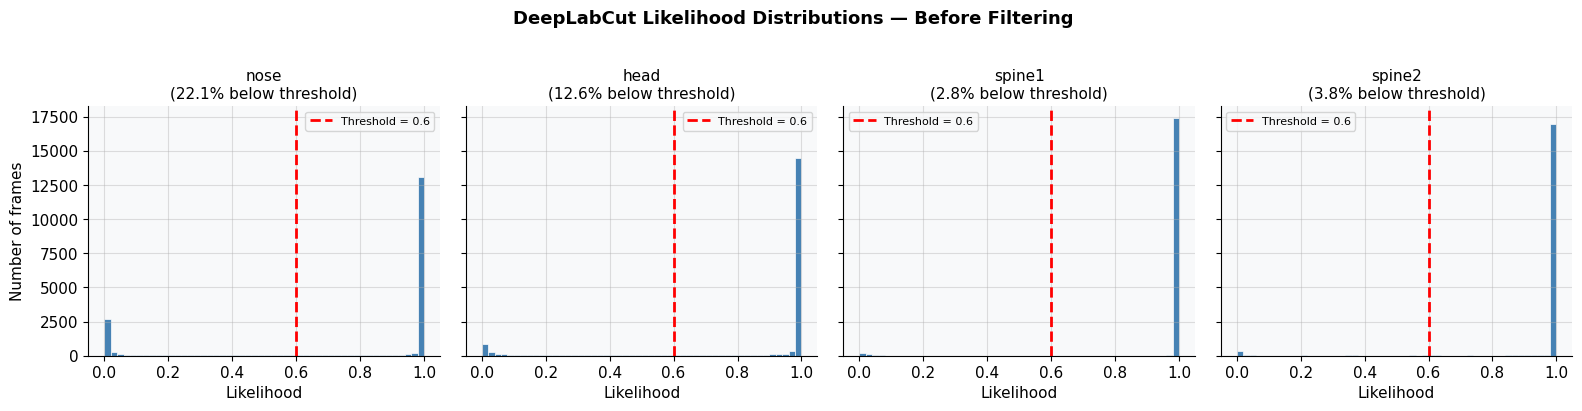

In [25]:
# ─────────────────────────────────────────────────────────────
# Step 1: Visualize likelihood distributions before filtering
# ─────────────────────────────────────────────────────────────

BODYPARTS   = ['nose', 'head', 'spine1', 'spine2']
LIKE_THRESH = 0.6  # frames below this are considered unreliable

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, bp in zip(axes, BODYPARTS):
    lk = dlc_raw[f'{bp}_likelihood']
    ax.hist(lk, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(LIKE_THRESH, color='red', linestyle='--', linewidth=2,
               label=f'Threshold = {LIKE_THRESH}')
    low_pct = (lk < LIKE_THRESH).mean() * 100
    ax.set_title(f'{bp}\n({low_pct:.1f}% below threshold)', fontsize=11)
    ax.set_xlabel('Likelihood')
    if ax == axes[0]:
        ax.set_ylabel('Number of frames')
    ax.legend(fontsize=8)

plt.suptitle('DeepLabCut Likelihood Distributions — Before Filtering', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [26]:
# ─────────────────────────────────────────────────────────────
# Step 2: Apply likelihood filter + interpolate short gaps
# ─────────────────────────────────────────────────────────────

def filter_and_interpolate(df, bodyparts, threshold=0.6, max_gap_frames=10):
    """
    Mask low-likelihood frames as NaN, then linearly interpolate short gaps.

    Parameters
    ----------
    df            : pd.DataFrame   Raw DLC dataframe
    bodyparts     : list of str    e.g. ['nose', 'head', 'spine1', 'spine2']
    threshold     : float          Likelihood cutoff (0–1)
    max_gap_frames: int            Only interpolate gaps shorter than this
    
    Returns
    -------
    clean : pd.DataFrame   Filtered + interpolated copy
    report: pd.DataFrame   Per-bodypart quality report
    """
    clean = df.copy()
    report_rows = []

    for bp in bodyparts:
        lk      = df[f'{bp}_likelihood']
        bad_mask = lk < threshold
        n_bad    = bad_mask.sum()

        # Mask bad frames as NaN
        clean.loc[bad_mask, f'{bp}_x'] = np.nan
        clean.loc[bad_mask, f'{bp}_y'] = np.nan

        # Interpolate short gaps only
        for coord in ['x', 'y']:
            col = f'{bp}_{coord}'
            s   = clean[col].copy()
            # Compute run lengths of NaN sequences
            is_nan   = s.isna()
            nan_runs = is_nan.ne(is_nan.shift()).cumsum()
            for run_id, grp in s.groupby(nan_runs):
                if grp.isna().all() and len(grp) <= max_gap_frames:
                    s.loc[grp.index] = np.nan  # will be interpolated
            clean[col] = s.interpolate(method='linear', limit=max_gap_frames,
                                        limit_direction='both')

        n_remaining_nan = clean[f'{bp}_x'].isna().sum()
        report_rows.append({
            'bodypart':         bp,
            'n_frames':         len(df),
            'n_bad_frames':     n_bad,
            'pct_bad':          round(n_bad / len(df) * 100, 2),
            'n_interpolated':   n_bad - n_remaining_nan,
            'n_still_nan':      n_remaining_nan,
        })

    return clean, pd.DataFrame(report_rows)


dlc_clean, quality_report = filter_and_interpolate(
    dlc_raw, BODYPARTS, threshold=LIKE_THRESH, max_gap_frames=10)

print("Quality Report:")
print(quality_report.to_string(index=False))
print(f"\nTotal frames: {len(dlc_raw)}")


Quality Report:
bodypart  n_frames  n_bad_frames  pct_bad  n_interpolated  n_still_nan
    nose     18032          3980    22.07            1567         2413
    head     18032          2274    12.61            1153         1121
  spine1     18032           497     2.76             208          289
  spine2     18032           691     3.83             498          193

Total frames: 18032


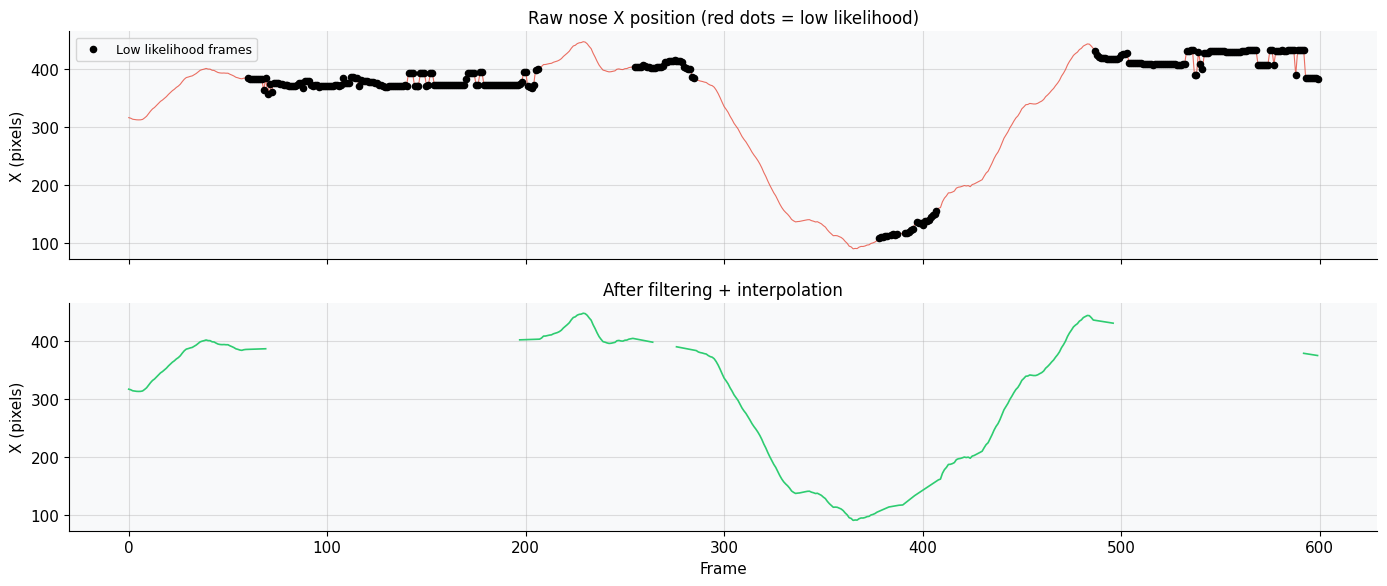

In [27]:
# ─────────────────────────────────────────────────────────────
# Step 3: Visualize a raw vs. clean segment (nose x-coordinate)
# ─────────────────────────────────────────────────────────────

t_start, t_end = 0, 600   # first 20 seconds

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

frames = dlc_raw['frame'].iloc[t_start:t_end]

ax1.plot(frames, dlc_raw['nose_x'].iloc[t_start:t_end],
         color='#e74c3c', linewidth=0.8, alpha=0.8)
bad = dlc_raw['nose_likelihood'].iloc[t_start:t_end] < LIKE_THRESH
ax1.scatter(frames[bad], dlc_raw['nose_x'].iloc[t_start:t_end][bad],
            color='black', s=20, zorder=5, label='Low likelihood frames')
ax1.set_title('Raw nose X position (red dots = low likelihood)', fontsize=12)
ax1.set_ylabel('X (pixels)')
ax1.legend(fontsize=9)

ax2.plot(frames, dlc_clean['nose_x'].iloc[t_start:t_end],
         color='#2ecc71', linewidth=1.2)
ax2.set_title('After filtering + interpolation', fontsize=12)
ax2.set_ylabel('X (pixels)')
ax2.set_xlabel('Frame')

plt.tight_layout()
plt.show()


---
## Part 3: Locomotor Feature Extraction

### 3.1 Trajectory Smoothing

Even after filtering, tracking data has frame-to-frame jitter due to camera resolution limits.  
We apply a **Gaussian-weighted moving average** to smooth positions:

$$x_{\text{smooth}}[t] = \sum_{k} w_k \, x[t+k], \quad \text{where } w_k \propto e^{-k^2/2\sigma^2}$$

A wider window → more smoothing, but erases fast events (twitches, quick turns).  
A good default for mouse tracking at 20 fps is a **5-frame window** (~167 ms).


In [28]:
# ─────────────────────────────────────────────────────────────
# Smooth all keypoint coordinates
# ─────────────────────────────────────────────────────────────

SMOOTH_WINDOW = 4  # frames  (~ 200 ms at 20 fps)

dlc = dlc_clean.copy()

for bp in BODYPARTS:
    for coord in ['x', 'y']:
        col = f'{bp}_{coord}'
        dlc[col] = uniform_filter1d(
            dlc_clean[col].fillna(method='ffill').fillna(method='bfill'),
            size=SMOOTH_WINDOW
        )

print(f"✓ Coordinates smoothed with window = {SMOOTH_WINDOW} frames")


✓ Coordinates smoothed with window = 4 frames


### 3.2 Speed

Instantaneous speed is the Euclidean distance traveled between consecutive frames, divided by the time step:

$$v[t] = \frac{\sqrt{(x[t] - x[t-1])^2 + (y[t] - y[t-1])^2}}{\Delta t}$$

Units: **pixels/second** (divide by pixels-per-cm to convert to cm/s if calibrated).


In [ ]:
# ─────────────────────────────────────────────────────────────
# Calculate speed from nose position
# ─────────────────────────────────────────────────────────────

def calculate_speed(x, y, dt, smooth_window=None):
    """
    Compute instantaneous speed from position time series.

    Parameters
    ----------
    x, y          : array-like   Position coordinates (pixels)
    dt            : float        Time step in seconds (1/FPS)
    smooth_window : int or None  If set, smooth speed with uniform filter

    Returns
    -------
    speed : np.ndarray  Speed in pixels/second (same length as input)
    """
    ## TODO: Compute speed as Euclidean distance between consecutive frames divided by dt
    speed = None

    if smooth_window:
        speed = uniform_filter1d(speed, size=smooth_window)

    return speed


dlc['speed'] = calculate_speed(dlc['nose_x'], dlc['nose_y'], dt=1/20, smooth_window=5)

# Summary statistics
print("Speed statistics (pixels/second):")
print(f"  Mean  : {dlc['speed'].mean():.1f}")
print(f"  Median: {dlc['speed'].median():.1f}")
print(f"  Std   : {dlc['speed'].std():.1f}")
print(f"  Max   : {dlc['speed'].max():.1f}")

# Classify: resting vs moving (threshold = 20 px/s as a starting point)
SPEED_THRESHOLD = 20  # px/s
dlc['is_moving'] = dlc['speed'] > SPEED_THRESHOLD
pct_moving = dlc['is_moving'].mean() * 100
print(f"\n  Moving (>{SPEED_THRESHOLD} px/s): {pct_moving:.1f}% of time")
print(f"  Resting             : {100-pct_moving:.1f}% of time")


Speed statistics (pixels/second):
  Mean  : 44.2
  Median: 25.9
  Std   : 50.5
  Max   : 532.8

  Moving (>20 px/s): 56.9% of time
  Resting             : 43.1% of time


In [ ]:
# def calculate_speed(x, y, dt, smooth_window=None): -->
#     """
#     Compute instantaneous speed from position time series.

#     Parameters
#     ----------
#     x, y          : array-like   Position coordinates (pixels)
#     dt            : float        Time step in seconds (1/FPS)
#     smooth_window : int or None  If set, smooth speed with uniform filter

#     Returns
#     -------
#     speed : np.ndarray  Speed in pixels/second (same length as input)
#     """
#     dx = np.diff(x, prepend=x[0])
#     dy = np.diff(y, prepend=y[0])
#     speed = np.sqrt(dx**2 + dy**2) / dt

#     if smooth_window:
#         speed = uniform_filter1d(speed, size=smooth_window)

#     return speed

### 3.3 Movement Direction

The **heading angle** (movement direction) is computed from the velocity vector:

$$\theta[t] = \arctan2\!\left(\Delta y[t],\; \Delta x[t]\right) \in [-\pi, \pi]$$

`arctan2` is preferred over plain `arctan` because it correctly handles all four quadrants.  
We only compute direction when the mouse is actually moving (speed > threshold), 
otherwise we inherit the last valid heading.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Calculate movement direction (heading angle)
# ─────────────────────────────────────────────────────────────

def calculate_direction(x, y, speed, speed_threshold=10):
    """
    Compute instantaneous heading angle in radians.
    Only updates when speed exceeds threshold; otherwise holds last angle.

    Parameters
    ----------
    x, y             : array-like  Positions
    speed            : array-like  Speed (px/s)
    speed_threshold  : float       Min speed to update heading

    Returns
    -------
    direction : np.ndarray  Heading angle in radians [-π, π]
    """
    ## TODO: Compute raw angle using arctan2 of position differences
    raw_angle = None
    # Only update direction when moving
    direction = raw_angle.copy()
    for t in range(1, len(direction)):
        if speed[t] < speed_threshold:
            direction[t] = direction[t-1]  # hold previous heading

    return direction


dlc['direction'] = calculate_direction(
    dlc['nose_x'], dlc['nose_y'], dlc['speed'], speed_threshold=10)

print("✓ Heading angles computed")
print(f"  Range: [{dlc['direction'].min():.2f}, {dlc['direction'].max():.2f}] radians")
print(f"  ({np.degrees(dlc['direction'].min()):.0f}° to {np.degrees(dlc['direction'].max()):.0f}°)")


✓ Heading angles computed
  Range: [-3.14, 3.14] radians
  (-180° to 180°)


In [ ]:
# def calculate_direction(x, y, speed, speed_threshold=10):
#     """
#     Compute instantaneous heading angle in radians.
#     Only updates when speed exceeds threshold; otherwise holds last angle.

#     Parameters
#     ----------
#     x, y             : array-like  Positions
#     speed            : array-like  Speed (px/s)
#     speed_threshold  : float       Min speed to update heading

#     Returns
#     -------
#     direction : np.ndarray  Heading angle in radians [-π, π]
#     """
#     dx = np.diff(x, prepend=x[0])
#     dy = np.diff(y, prepend=y[0])
#     raw_angle = np.arctan2(dy, dx)

#     # Only update direction when moving
#     direction = raw_angle.copy()
#     for t in range(1, len(direction)):
#         if speed[t] < speed_threshold:
#             direction[t] = direction[t-1]  # hold previous heading

#     return direction


### 3.4 Distance from Arena Center

A classic measure of **thigmotaxis** (wall-hugging): anxious mice tend to stay near the walls,  
while more exploratory animals venture to the center.

$$d_{\text{center}}[t] = \sqrt{(x[t] - x_c)^2 + (y[t] - y_c)^2}$$


In [ ]:
# ─────────────────────────────────────────────────────────────
# Distance from arena center
# ─────────────────────────────────────────────────────────────
ARENA_W, ARENA_H = 535, 528 ## pre-defined arena dimensions (pixels)
ARENA_CENTER_X = ARENA_W / 2  # 267.5
ARENA_CENTER_Y = ARENA_H / 2  # 264.0

dlc['dist_center'] = np.sqrt(
    (dlc['nose_x'] - ARENA_CENTER_X)**2 +
    (dlc['nose_y'] - ARENA_CENTER_Y)**2
)

print(f"Arena center: ({ARENA_CENTER_X}, {ARENA_CENTER_Y})")
print(f"Mean distance from center: {dlc['dist_center'].mean():.1f} px")


Arena center: (267.5, 264.0)
Mean distance from center: 199.8 px


In [36]:
# ─────────────────────────────────────────────────────────────
# Body axis orientation (spine1 → head vector)
# ─────────────────────────────────────────────────────────────

dlc['body_angle'] = np.arctan2(
    dlc['head_y'] - dlc['spine1_y'],
    dlc['head_x'] - dlc['spine1_x']
)

print("✓ All locomotor features computed!")
print("\nFeature summary:")
for feat in ['speed', 'direction', 'dist_center', 'body_angle']:
    print(f"  {feat:15s}: mean={dlc[feat].mean():.2f}, std={dlc[feat].std():.2f}")


✓ All locomotor features computed!

Feature summary:
  speed          : mean=44.16, std=50.46
  direction      : mean=0.01, std=1.85
  dist_center    : mean=199.80, std=67.13
  body_angle     : mean=0.24, std=1.90


---
## Part 4: Visualize Locomotor Features

### 4.1 Full Trajectory + Speed Heatmap


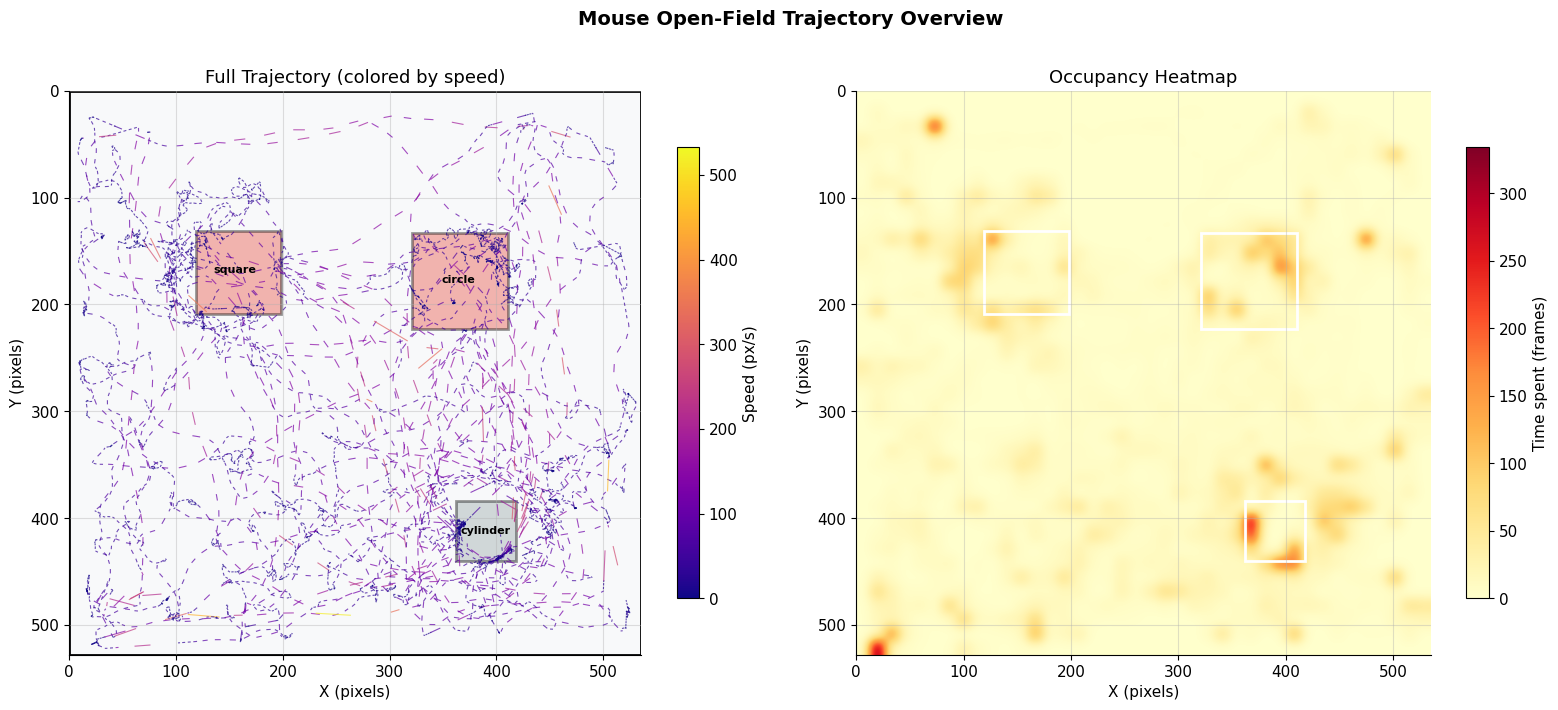

In [37]:
# ─────────────────────────────────────────────────────────────
# Trajectory colored by speed
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: colored trajectory ──
ax = axes[0]
speed_norm = (dlc['speed'] - dlc['speed'].min()) / (dlc['speed'].max() - dlc['speed'].min())
cmap = plt.cm.plasma

for t in range(0, len(dlc) - 1, 3):  # subsample for speed
    ax.plot(dlc['nose_x'].iloc[t:t+2],
            dlc['nose_y'].iloc[t:t+2],
            color=cmap(speed_norm.iloc[t]), linewidth=0.8, alpha=0.7)

# Draw arena border
arena_rect = plt.Rectangle((0, 0), ARENA_W, ARENA_H,
                             linewidth=2, edgecolor='black', facecolor='none')
ax.add_patch(arena_rect)

# Draw objects
obj_colors = {'object_1_square': '#e74c3c', 'object_2_circle': '#e74c3c', 
              'object_3_cylinder': '#95a5a6'}
for _, row in obj_df.iterrows():
    w = row['bbox_x2'] - row['bbox_x1']
    h = row['bbox_y2'] - row['bbox_y1']
    rect = plt.Rectangle((row['bbox_x1'], row['bbox_y1']), w, h,
                          linewidth=2, edgecolor='black',
                          facecolor=obj_colors.get(row['object'], 'gray'), alpha=0.4)
    ax.add_patch(rect)
    ax.text(row['center_x'], row['center_y'], row['object'].split('_')[-1],
            ha='center', va='center', fontsize=8, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(dlc['speed'].min(), dlc['speed'].max()))
plt.colorbar(sm, ax=ax, label='Speed (px/s)', shrink=0.8)
ax.set_xlim(0, ARENA_W)
ax.set_ylim(ARENA_H, 0)  # flip y so (0,0) is top-left
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_title('Full Trajectory (colored by speed)', fontsize=13)
ax.set_aspect('equal')

# ── Right: occupancy heatmap ──
ax2 = axes[1]
heatmap, xedges, yedges = np.histogram2d(
    dlc['nose_x'], dlc['nose_y'],
    bins=[40, 40],
    range=[[0, ARENA_W], [0, ARENA_H]]
)
im = ax2.imshow(heatmap.T, origin='upper', aspect='auto',
                extent=[0, ARENA_W, ARENA_H, 0],
                cmap='YlOrRd', interpolation='gaussian')
plt.colorbar(im, ax=ax2, label='Time spent (frames)', shrink=0.8)
for _, row in obj_df.iterrows():
    w = row['bbox_x2'] - row['bbox_x1']
    h = row['bbox_y2'] - row['bbox_y1']
    rect = plt.Rectangle((row['bbox_x1'], row['bbox_y1']), w, h,
                          linewidth=2, edgecolor='white', facecolor='none')
    ax2.add_patch(rect)

ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')
ax2.set_title('Occupancy Heatmap', fontsize=13)

plt.suptitle('Mouse Open-Field Trajectory Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


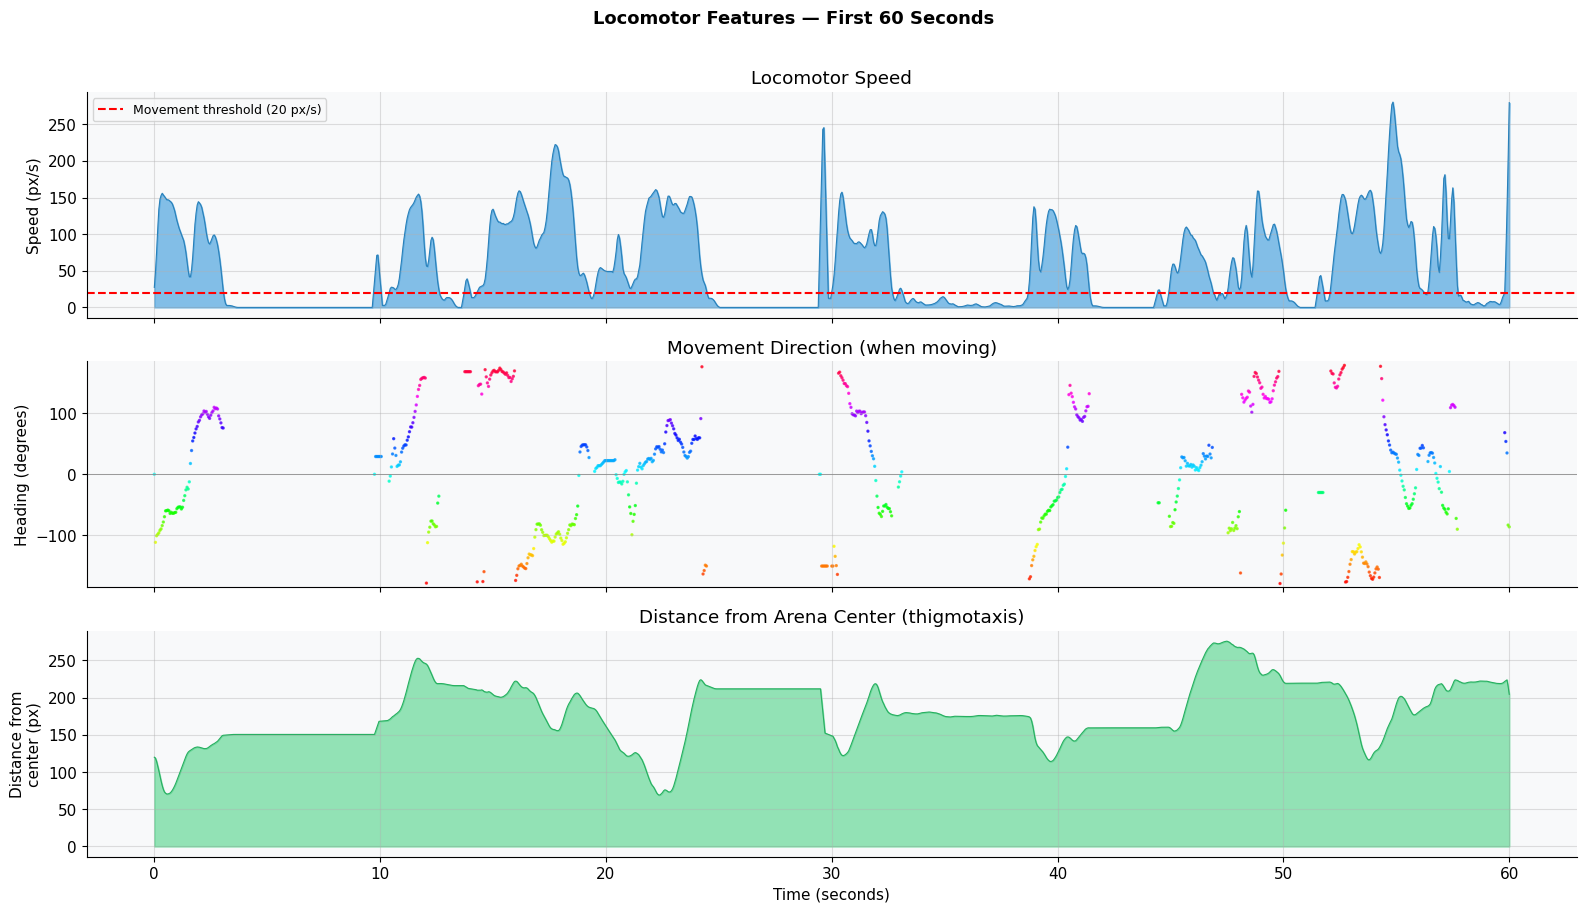

In [38]:
# ─────────────────────────────────────────────────────────────
# Speed and direction over time (first 60 seconds)
# ─────────────────────────────────────────────────────────────

t_mask = dlc['time'] <= 60
t = dlc.loc[t_mask, 'time']

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

# Speed
axes[0].fill_between(t, dlc.loc[t_mask, 'speed'], alpha=0.6, color='#3498db')
axes[0].plot(t, dlc.loc[t_mask, 'speed'], color='#2980b9', linewidth=0.8)
axes[0].axhline(SPEED_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
                label=f'Movement threshold ({SPEED_THRESHOLD} px/s)')
axes[0].set_ylabel('Speed (px/s)')
axes[0].set_title('Locomotor Speed')
axes[0].legend(fontsize=9)

# Direction (only when moving)
moving_t = dlc.loc[t_mask & dlc['is_moving'], 'time']
moving_dir = dlc.loc[t_mask & dlc['is_moving'], 'direction']
axes[1].scatter(moving_t, np.degrees(moving_dir),
                c=np.degrees(moving_dir), cmap='hsv', s=2, alpha=0.7)
axes[1].set_ylabel('Heading (degrees)')
axes[1].set_title('Movement Direction (when moving)')
axes[1].set_ylim(-185, 185)
axes[1].axhline(0, color='gray', linewidth=0.5)

# Distance from center
axes[2].fill_between(t, dlc.loc[t_mask, 'dist_center'], alpha=0.5, color='#2ecc71')
axes[2].plot(t, dlc.loc[t_mask, 'dist_center'], color='#27ae60', linewidth=0.8)
axes[2].set_ylabel('Distance from\ncenter (px)')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_title('Distance from Arena Center (thigmotaxis)')

plt.suptitle('Locomotor Features — First 60 Seconds', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## ✏️ Exercise : Body Length & Posture Feature

### Background

The **body length** — distance from nose to spine2 — is a useful postural feature.  
When a mouse is sniffing an object it often stretches (body length increases);  
when grooming or resting it compresses (body length decreases).

$$L[t] = \sqrt{(x_{\text{nose}}[t] - x_{\text{spine2}}[t])^2 + (y_{\text{nose}}[t] - y_{\text{spine2}}[t])^2}$$

### Your Task
Complete the function and plot body length over time.

this can help us know the dimension of the arena ect, given that the adult trunk length is around 6.3–10.2 cm


✓ Function runs! Check the plot to see if the result looks realistic.


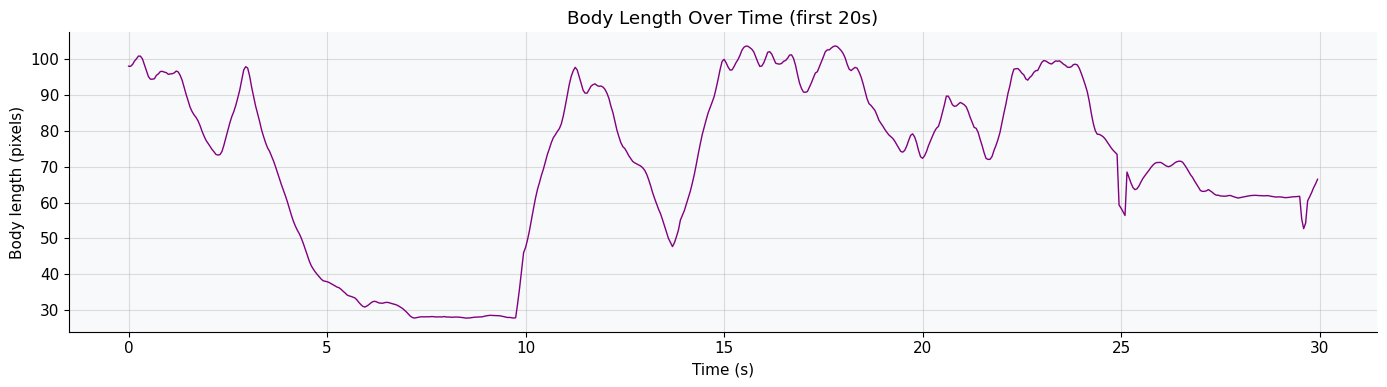

In [ ]:
# =============================================================================
# EXERCISE 1: Calculate body length from nose to spine2
# =============================================================================

def calculate_body_length(df):
    """
    Compute instantaneous body length (nose → spine2 distance).

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: nose_x, nose_y, spine2_x, spine2_y

    Returns
    -------
    body_length : np.ndarray  Length in pixels, shape (n_frames,)
    """
    # TODO: Compute Euclidean distance between nose and spine2
    # HINT: Use np.sqrt() and the formula above
    # HINT: df['nose_x'] - df['spine2_x'] gives you Δx

    # YOUR CODE HERE
    body_length = np.zeros(len(df))  # placeholder

    return body_length


# Test your function:
body_length = calculate_body_length(dlc)

# Check
assert body_length.shape[0] == len(dlc), "Array length must match number of frames"
assert np.all(body_length >= 0), "Length should always be non-negative"
print("✓ Function runs! Check the plot to see if the result looks realistic.")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dlc['time'][:600], body_length[:600], color='purple', linewidth=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Body length (pixels)')
ax.set_title('Body Length Over Time (first 20s)')
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# SOLUTION — Exercise 1
# =============================================================================
# Uncomment to reveal:

# def calculate_body_length(df):
#     dx = df['nose_x'].values - df['spine2_x'].values
#     dy = df['nose_y'].values - df['spine2_y'].values
#     return np.sqrt(dx**2 + dy**2)
#
# body_length = calculate_body_length(dlc)
# print(f"Mean body length: {body_length.mean():.1f} px")
# print(f"Std: {body_length.std():.1f} px")


---
## Part 5: Object Interaction Detection

### Defining an interaction

We say the mouse is **interacting with an object** when the nose keypoint  
is within a threshold distance $d_{\text{thresh}}$ of the object center:

$$\text{interaction}[t] = \begin{cases} 1 & \text{if } d(\text{nose},\; \text{obj\_center})[t] < d_{\text{thresh}} \\ 0 & \text{otherwise} \end{cases}$$

A natural choice for the threshold is **1.5 × the object's half-diagonal** (bounding box diagonal / 2 × 1.5), which approximates the object's "interaction zone".

$$d_{\text{thresh}} = 1.5 \times \frac{\sqrt{w^2 + h^2}}{2}$$


In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 1: Compute nose-to-object distances for every frame
# ─────────────────────────────────────────────────────────────

def compute_distances_to_objects(df, obj_df, bodypart='nose'):
    """
    Compute Euclidean distance from a keypoint to each object center.

    Parameters
    ----------
    df       : pd.DataFrame  Tracking data with {bodypart}_x, {bodypart}_y
    obj_df   : pd.DataFrame  Object info with center_x, center_y, object
    bodypart : str           Which keypoint to use

    Returns
    -------
    dist_df : pd.DataFrame   Columns: frame, time, dist_to_{obj_name}, ...
    """
    dist_df = df[['frame', 'time']].copy()

    for _, row in obj_df.iterrows():
        col = f"dist_to_{row['object']}"
        # TODO: Compute distance from bodypart to object center using Euclidean formula
        dist_df[col] = None

    return dist_df


dist_df = compute_distances_to_objects(dlc, obj_df, bodypart='nose')

print("Distance DataFrame:")
print(dist_df.head())
print(f"\nDistance range per object:")
for _, row in obj_df.iterrows():
    col = f"dist_to_{row['object']}"
    print(f"  {row['object']}: min={dist_df[col].min():.1f}, "
          f"mean={dist_df[col].mean():.1f}, max={dist_df[col].max():.1f} px")


Distance DataFrame:
   frame  time  dist_to_object_1_square  dist_to_object_2_circle  \
0      0  0.00               262.042718               202.303847   
1      1  0.05               260.897391               201.328508   
2      2  0.10               256.967889               197.308076   
3      3  0.15               251.508614               191.496333   
4      4  0.20               245.841327               185.171774   

   dist_to_object_3_cylinder  
0                  83.186219  
1                  84.091542  
2                  86.935677  
3                  91.035273  
4                  95.506006  

Distance range per object:
  object_1_square: min=2.2, mean=248.6, max=497.1 px
  object_2_circle: min=0.6, mean=233.7, max=484.0 px
  object_3_cylinder: min=13.9, mean=226.5, max=536.0 px


In [ ]:

# def compute_distances_to_objects(df, obj_df, bodypart='nose'):
#     """
#     Compute Euclidean distance from a keypoint to each object center.

#     Parameters
#     ----------
#     df       : pd.DataFrame  Tracking data with {bodypart}_x, {bodypart}_y
#     obj_df   : pd.DataFrame  Object info with center_x, center_y, object
#     bodypart : str           Which keypoint to use

#     Returns
#     -------
#     dist_df : pd.DataFrame   Columns: frame, time, dist_to_{obj_name}, ...
#     """
#     dist_df = df[['frame', 'time']].copy()

#     for _, row in obj_df.iterrows():
#         col = f"dist_to_{row['object']}"
#         dist_df[col] = np.sqrt(
#             (df[f'{bodypart}_x'] - row['center_x'])**2 +
#             (df[f'{bodypart}_y'] - row['center_y'])**2
#         )

#     return dist_df

In [43]:
# ─────────────────────────────────────────────────────────────
# Step 2: Set interaction thresholds & create binary masks
# ─────────────────────────────────────────────────────────────

def compute_interaction_thresholds(obj_df, scale=1.5):
    """
    Auto-compute interaction distance threshold from bounding box size.

    Returns
    -------
    thresholds : dict  {object_name: threshold_pixels}
    """
    thresholds = {}
    for _, row in obj_df.iterrows():
        w = row['bbox_x2'] - row['bbox_x1']
        h = row['bbox_y2'] - row['bbox_y1']
        half_diag = np.sqrt(w**2 + h**2) / 2
        thresholds[row['object']] = half_diag * scale
    return thresholds


thresholds = compute_interaction_thresholds(obj_df, scale=1.5)

print("Interaction thresholds:")
for obj, thresh in thresholds.items():
    print(f"  {obj}: {thresh:.1f} px")

# Create binary interaction columns
for obj_name, thresh in thresholds.items():
    dist_col = f'dist_to_{obj_name}'
    dlc[f'near_{obj_name}'] = (dist_df[dist_col] < thresh).astype(int)

# Also store distances in main df
for col in [c for c in dist_df.columns if c.startswith('dist_')]:
    dlc[col] = dist_df[col].values

print("\n✓ Interaction flags added to main dataframe")
print("New columns:", [c for c in dlc.columns if c.startswith('near_')])


Interaction thresholds:
  object_1_square: 83.3 px
  object_2_circle: 95.5 px
  object_3_cylinder: 59.4 px

✓ Interaction flags added to main dataframe
New columns: ['near_object_1_square', 'near_object_2_circle', 'near_object_3_cylinder']


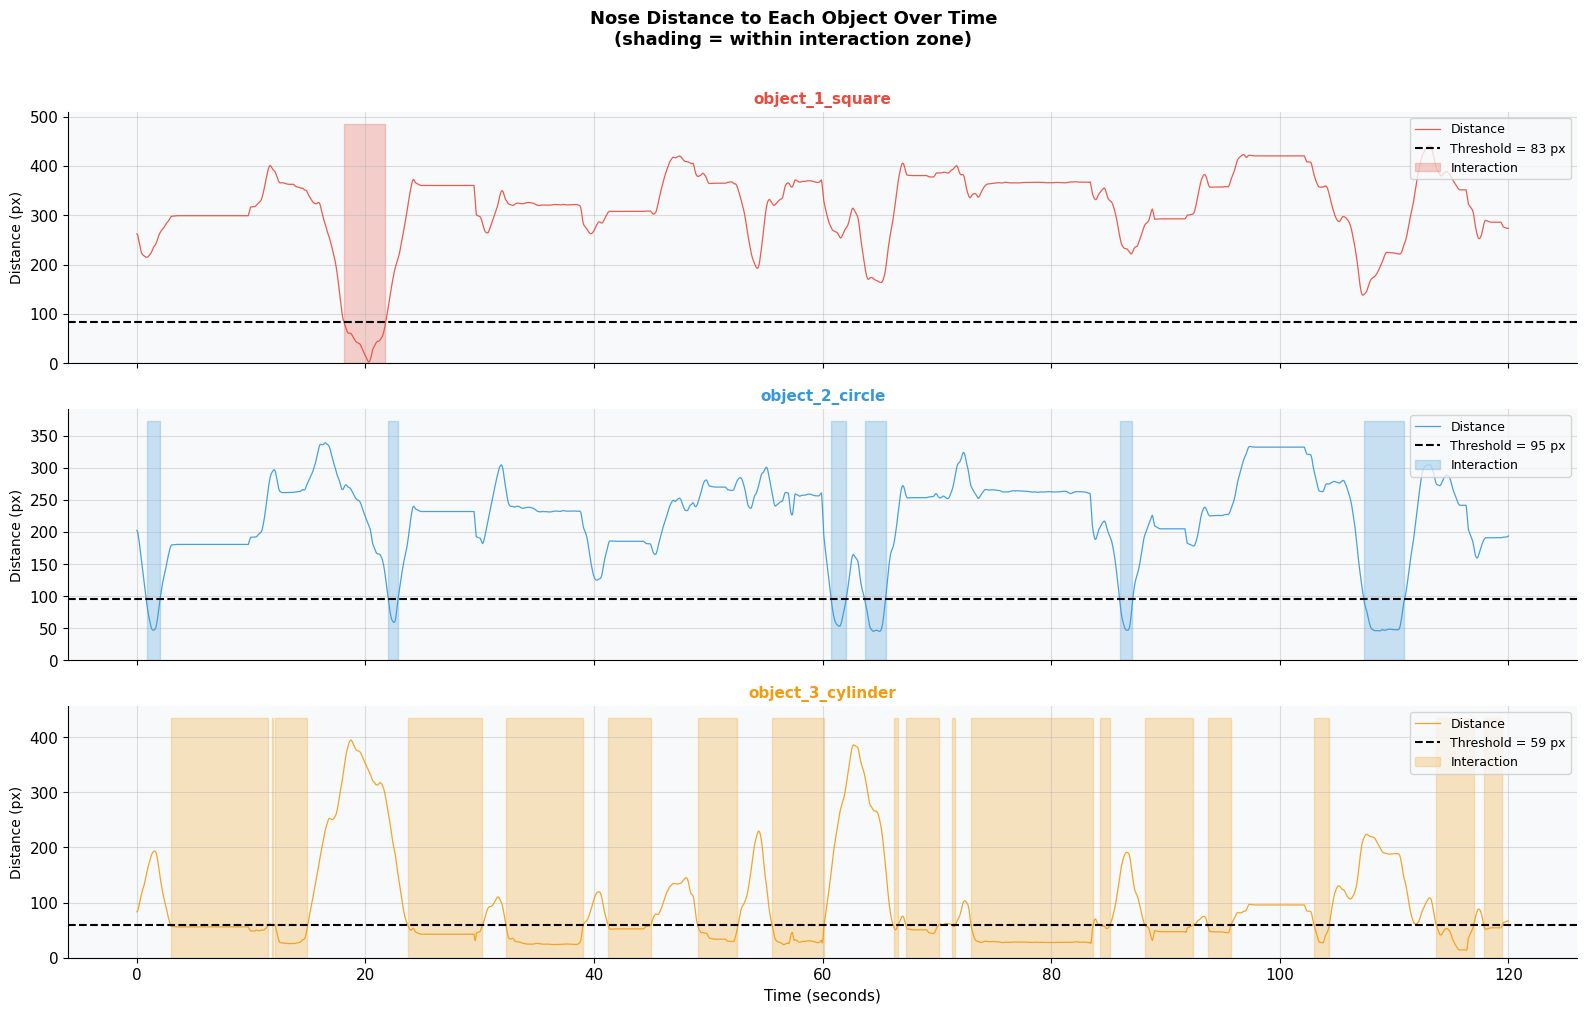

In [44]:
# ─────────────────────────────────────────────────────────────
# Visualize distance to each object over time (first 120 s)
# ─────────────────────────────────────────────────────────────

COLORS_OBJ = {
    'object_1_square':   '#e74c3c',
    'object_2_circle':   '#3498db',
    'object_3_cylinder': '#f39c12',
}

t_mask = dlc['time'] <= 120
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, (_, row) in zip(axes, obj_df.iterrows()):
    obj = row['object']
    color = COLORS_OBJ[obj]
    dist_col = f'dist_to_{obj}'
    thresh = thresholds[obj]

    ax.plot(dlc.loc[t_mask, 'time'], dlc.loc[t_mask, dist_col],
            color=color, linewidth=0.9, alpha=0.9, label='Distance')
    ax.axhline(thresh, color='black', linestyle='--', linewidth=1.5,
               label=f'Threshold = {thresh:.0f} px')

    # Shade interaction periods
    interacting = (dlc.loc[t_mask, dist_col] < thresh)
    ax.fill_between(dlc.loc[t_mask, 'time'], 0,
                    dlc.loc[t_mask, dist_col].max() * 1.1,
                    where=interacting, alpha=0.25, color=color, label='Interaction')

    ax.set_ylabel('Distance (px)', fontsize=10)
    ax.set_title(f'{obj}', fontsize=11, color=color, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(0, None)

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.suptitle('Nose Distance to Each Object Over Time\n(shading = within interaction zone)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 🎯 Excersise: re-chceck, Does the threshold make sense?
Visulize the trajectory when the animal is detected to interact with the object, change the threshold if it doesn't make sense.

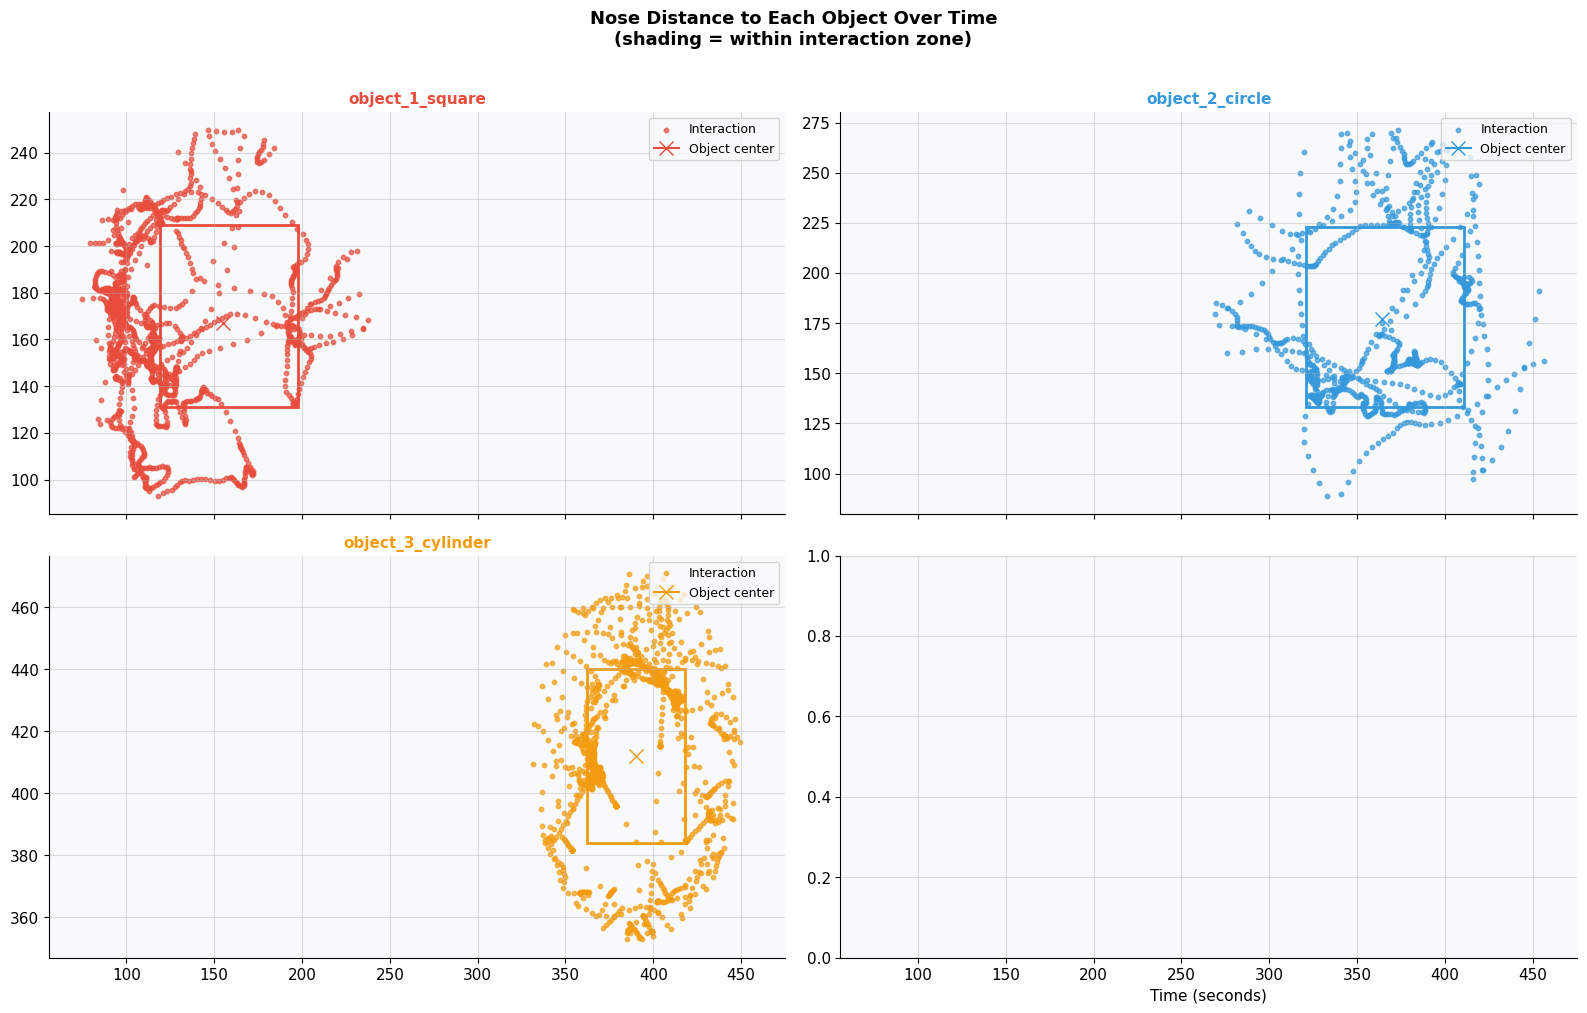

In [ ]:
t_mask = dlc['time'] <= 500

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, obj_df.iterrows()):
    obj = row['object']
    color = COLORS_OBJ[obj]
    dist_col = f'dist_to_{obj}'
    thresh = thresholds[obj]

    # Shade interaction periods
    interacting = (dlc.loc[t_mask, dist_col] < thresh)
    ## scatter the trajectoy when interacting for x and y together 
    ##TODO: plot the trajectory points when interacting with the object (use dlc['nose_x'] and dlc['nose_y'])
    ax.scatter(...)

    
    # plot the obejct edge and center 
    w = row['bbox_x2'] - row['bbox_x1']
    h = row['bbox_y2'] - row['bbox_y1']
    rect = plt.Rectangle((row['bbox_x1'], row['bbox_y1']), w, h,
                          linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.plot(row['center_x'], row['center_y'], marker='x', color=color, markersize=10, label='Object center')    
    ax.set_title(f'{obj}', fontsize=11, color=color, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    
axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.suptitle('Nose Distance to Each Object Over Time\n(shading = within interaction zone)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# t_mask = dlc['time'] <= 500

# fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
# axes = axes.flatten()

# for ax, (_, row) in zip(axes, obj_df.iterrows()):
#     obj = row['object']
#     color = COLORS_OBJ[obj]
#     dist_col = f'dist_to_{obj}'
#     thresh = thresholds[obj]

#     # Shade interaction periods
#     interacting = (dlc.loc[t_mask, dist_col] < thresh)
#     ## scatter the trajectoy when interacting for x and y together 
#     ax.scatter(dlc.loc[t_mask & interacting, 'nose_x'], dlc.loc[t_mask & interacting, 'nose_y'],
#                color=color, s=10, alpha=0.7, label='Interaction')
#     # plot the obejct edge and center 
#     w = row['bbox_x2'] - row['bbox_x1']
#     h = row['bbox_y2'] - row['bbox_y1']
#     rect = plt.Rectangle((row['bbox_x1'], row['bbox_y1']), w, h,
#                           linewidth=2, edgecolor=color, facecolor='none')
#     ax.add_patch(rect)
#     ax.plot(row['center_x'], row['center_y'], marker='x', color=color, markersize=10, label='Object center')    
#     ax.set_title(f'{obj}', fontsize=11, color=color, fontweight='bold')
#     ax.legend(fontsize=9, loc='upper right')
    
# axes[-1].set_xlabel('Time (seconds)', fontsize=11)
# plt.suptitle('Nose Distance to Each Object Over Time\n(shading = within interaction zone)',
#              fontsize=13, fontweight='bold', y=1.01)
# plt.tight_layout()
# plt.show()

---
## Part 6: Interaction Bout Detection

A **bout** is a contiguous block of frames where the interaction flag is `1`.  
We apply two additional criteria:
- **Minimum bout duration**: ignore very brief detections (< `min_duration` seconds) — likely tracking noise
- **Gap merging**: if two bouts are separated by < `merge_gap` seconds, merge them into one  
  (the mouse briefly poked its head away but was still exploring the object)

### Algorithm

```
raw bouts  →  [merge short gaps]  →  [remove short bouts]  →  final bouts
```


In [ ]:
# ─────────────────────────────────────────────────────────────
# Bout detection with gap merging and minimum duration filter
# ─────────────────────────────────────────────────────────────

def detect_bouts(binary_signal, time_arr, fps,
                 min_duration_s=0.2, merge_gap_s=0.5):
    """
    Detect contiguous bouts from a binary (0/1) signal.

    Parameters
    ----------
    binary_signal  : array-like  1 = interacting, 0 = not
    time_arr       : array-like  Time in seconds (same length)
    fps            : float       Frames per second (for duration calculation)
    min_duration_s : float       Bouts shorter than this are discarded (seconds)
    merge_gap_s    : float       Gaps shorter than this are bridged (seconds)

    Returns
    -------
    bouts : pd.DataFrame
        Columns: start_frame, end_frame, start_time, end_time, duration_s
    """
    signal = np.asarray(binary_signal).astype(int)
    n = len(signal)

    # Find raw transitions
    changes = np.diff(signal, prepend=0, append=0)
    starts  = np.where(changes ==  1)[0]
    ends    = np.where(changes == -1)[0]

    if len(starts) == 0:
        return pd.DataFrame(columns=['start_frame','end_frame',
                                     'start_time','end_time','duration_s'])

    # ── Merge bouts separated by short gaps ──
    merge_gap_frames = int(merge_gap_s * fps)
    merged_starts, merged_ends = [starts[0]], [ends[0]]

    for s, e in zip(starts[1:], ends[1:]):
        if s - merged_ends[-1] <= merge_gap_frames:
            merged_ends[-1] = e          # extend previous bout
        else:
            merged_starts.append(s)
            merged_ends.append(e)

    # ── Filter by minimum duration ──
    min_frames = int(min_duration_s * fps)
    bouts = []
    for s, e in zip(merged_starts, merged_ends):
        dur_frames = e - s
        if dur_frames >= min_frames:
            bouts.append({
                'start_frame': int(s),
                'end_frame':   int(e - 1),
                'start_time':  float(time_arr[s]),
                'end_time':    float(time_arr[min(e - 1, n - 1)]),
                'duration_s':  dur_frames / fps,
            })

    return pd.DataFrame(bouts)


# ── Detect bouts for each object ──
all_bouts = []
for _, row in obj_df.iterrows():
    obj = row['object']
    near_col = f'near_{obj}'
    ## TODO: try with different parameters for min_duration_s and merge_gap_s to see how it affects the results
    min_duration_s = None  # minimum duration of an interaction bout (seconds)
    merge_gap_s = None     # maximum gap to merge separate bouts (seconds
    bouts = detect_bouts(
        dlc[near_col].values,
        dlc['time'].values,
        fps=FPS,
        min_duration_s=min_duration_s,
        merge_gap_s = merge_gap_s
    )
    bouts['object'] = obj
    all_bouts.append(bouts)

bouts_df = pd.concat(all_bouts, ignore_index=True)

print(f"Total interaction bouts detected: {len(bouts_df)}")
print("\nBouts per object:")
print(bouts_df.groupby('object').size().rename('n_bouts'))
print("\nFirst 5 bouts:")
print(bouts_df.head().to_string(index=False))


Total interaction bouts detected: 84

Bouts per object:
object
object_1_square      17
object_2_circle      24
object_3_cylinder    43
Name: n_bouts, dtype: int64

First 5 bouts:
 start_frame  end_frame  start_time  end_time  duration_s          object
         363        435       18.15     21.75        3.65 object_1_square
        2770       2794      138.50    139.70        1.25 object_1_square
        2967       3107      148.35    155.35        7.05 object_1_square
        4840       5120      242.00    256.00       14.05 object_1_square
        5243       5366      262.15    268.30        6.20 object_1_square


---
##  Bout Visualization Timeline


Create a **timeline raster plot** showing when bouts occur for each object.  
This is a standard visualization in behavioral neuroscience (similar to spike rasters).

Each row = one object, each horizontal bar = one interaction bout.

**Starter code** is provided — fill in the `ax.broken_barh()` call.

**Hint**: `broken_barh(xranges, yrange)` where `xranges` is a list of `(start, width)` tuples.


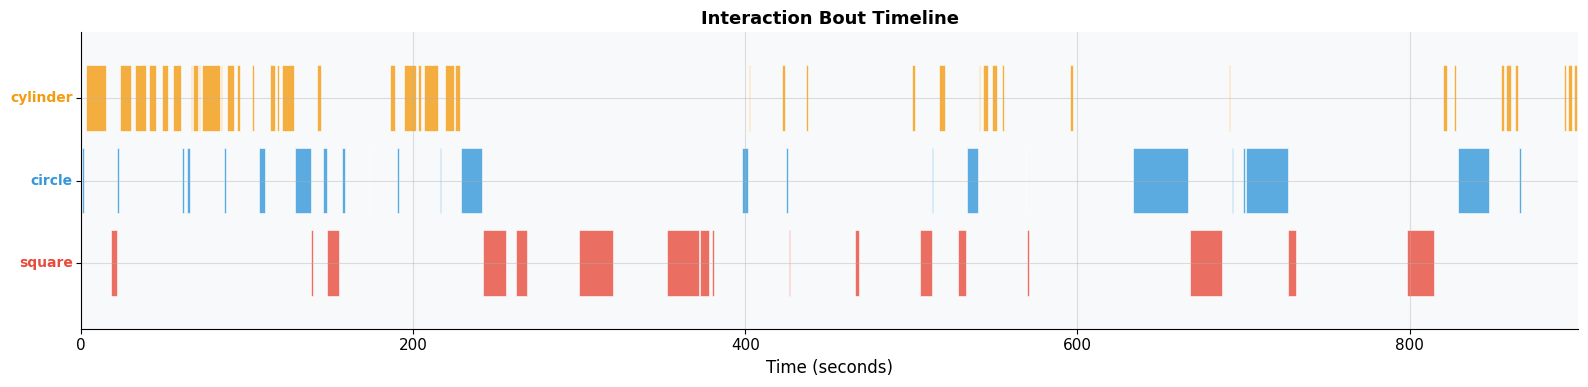

In [55]:
# =============================================================================
# SOLUTION — Exercise 2
# =============================================================================
# Uncomment to reveal:
obj_names = obj_df['object'].tolist()
obj_colors_list = [COLORS_OBJ[o] for o in obj_names]

fig, ax = plt.subplots(figsize=(16, 4))
for i, (obj, color) in enumerate(zip(obj_names, obj_colors_list)):
    obj_bouts = bouts_df[bouts_df['object'] == obj]
    xranges = [(row['start_time'], row['duration_s']) for _, row in obj_bouts.iterrows()]
    ax.broken_barh(xranges, (i - 0.4, 0.8), facecolors=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.text(-5, i, obj.split('_', 2)[-1], ha='right', va='center',
            fontsize=10, color=color, fontweight='bold')
ax.set_yticks(range(len(obj_names)))
ax.set_yticklabels([])
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_xlim(0, DURATION)
ax.set_ylim(-0.8, len(obj_names) - 0.2)
ax.set_title('Interaction Bout Timeline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🎯 Excerise Part 7: Quantify & Compare Object Exploration

We now compute two canonical measures from **novel object recognition (NOR)** tasks:

| Metric | Formula | Interpretation |
|--------|---------|---------------|
| **Bout count** | $N_{\text{bouts}}$ | How many times the animal visited the object |
| **Total duration** | $\sum_i d_i$ | Total seconds spent near the object |
| **Mean bout duration** | $\bar{d} = \frac{\sum d_i}{N}$ | Average visit length |
| **Discrimination Index** | $DI = \frac{t_A - t_B}{t_A + t_B}$ | Preference for object A over B (−1 to +1) |


In [ ]:
# ─────────────────────────────────────────────────────────────
# Compute summary statistics per object
# ─────────────────────────────────────────────────────────────

summary_rows = []
for _, row in obj_df.iterrows():
    obj = row['object']
    obj_bouts = bouts_df[bouts_df['object'] == obj]
    
    
    ## TODO: Compute number of bouts, total duration, mean duration, median duration, and percentage of time near object
    n_bouts       = None
    total_dur     = None
    mean_dur      =None
    median_dur    = None
    pct_time      = (total_dur / DURATION) * 100

    summary_rows.append({
        'object':          obj,
        'n_bouts':         n_bouts,
        'total_duration_s':round(total_dur, 2),
        'mean_bout_s':     round(mean_dur, 2),
        'median_bout_s':   round(median_dur, 2),
        'pct_time_near':   round(pct_time, 1),
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 65)
print("OBJECT EXPLORATION SUMMARY")
print("=" * 65)
print(summary_df.to_string(index=False))

# Discrimination Index (pairwise)
print("\nDiscrimination Indices:")
objects = summary_df['object'].tolist()
for i in range(len(objects)):
    for j in range(i+1, len(objects)):
        tA = summary_df.loc[i, 'total_duration_s']
        tB = summary_df.loc[j, 'total_duration_s']
        DI = (tA - tB) / (tA + tB) if (tA + tB) > 0 else 0
        print(f"  DI({objects[i].split('_')[-1]} vs {objects[j].split('_')[-1]}): {DI:+.3f}")
        print(f"    (positive = more time near {objects[i].split('_')[-1]})")


OBJECT EXPLORATION SUMMARY
           object  n_bouts  total_duration_s  mean_bout_s  median_bout_s  pct_time_near
  object_1_square       17            134.70         7.92           5.35           14.9
  object_2_circle       24            130.75         5.45           1.27           14.5
object_3_cylinder       43            139.20         3.24           2.50           15.4

Discrimination Indices:
  DI(square vs circle): +0.015
    (positive = more time near square)
  DI(square vs cylinder): -0.016
    (positive = more time near square)
  DI(circle vs cylinder): -0.031
    (positive = more time near circle)


In [ ]:

# summary_rows = []
# for _, row in obj_df.iterrows():
#     obj = row['object']
#     obj_bouts = bouts_df[bouts_df['object'] == obj]

#     n_bouts       = len(obj_bouts)
#     total_dur     = obj_bouts['duration_s'].sum()
#     mean_dur      = obj_bouts['duration_s'].mean() if n_bouts > 0 else 0
#     median_dur    = obj_bouts['duration_s'].median() if n_bouts > 0 else 0
#     pct_time      = (total_dur / DURATION) * 100

#     summary_rows.append({
#         'object':          obj,
#         'n_bouts':         n_bouts,
#         'total_duration_s':round(total_dur, 2),
#         'mean_bout_s':     round(mean_dur, 2),
#         'median_bout_s':   round(median_dur, 2),
#         'pct_time_near':   round(pct_time, 1),
#     })

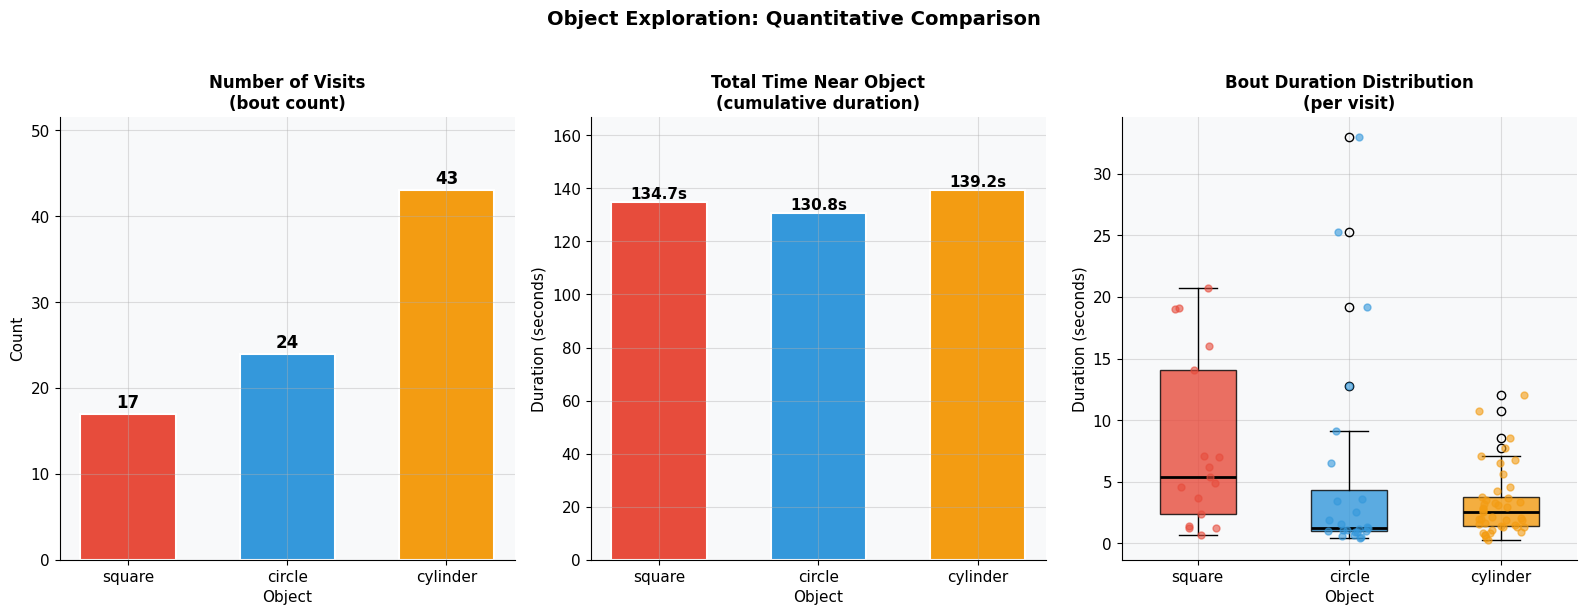

In [57]:
# ─────────────────────────────────────────────────────────────
# Visualization: bout count + total duration comparison
# ─────────────────────────────────────────────────────────────

short_names = [o.split('_', 2)[-1] for o in summary_df['object']]
colors_list = [COLORS_OBJ[o] for o in summary_df['object']]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── 1. Bout count ──
ax = axes[0]
bars = ax.bar(short_names, summary_df['n_bouts'], color=colors_list,
              edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, summary_df['n_bouts']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Number of Visits\n(bout count)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Object')
ax.set_ylim(0, summary_df['n_bouts'].max() * 1.2)

# ── 2. Total duration ──
ax = axes[1]
bars = ax.bar(short_names, summary_df['total_duration_s'], color=colors_list,
              edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, summary_df['total_duration_s']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Total Time Near Object\n(cumulative duration)', fontsize=12, fontweight='bold')
ax.set_ylabel('Duration (seconds)')
ax.set_xlabel('Object')
ax.set_ylim(0, summary_df['total_duration_s'].max() * 1.2)

# ── 3. Bout duration distribution (box plot) ──
ax = axes[2]
data_per_obj = [
    bouts_df.loc[bouts_df['object'] == o, 'duration_s'].values
    for o in summary_df['object']
]
bp = ax.boxplot(data_per_obj, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Overlay individual points
for i, (data, color) in enumerate(zip(data_per_obj, colors_list)):
    jitter = np.random.uniform(-0.15, 0.15, size=len(data))
    ax.scatter(np.full(len(data), i+1) + jitter, data,
               color=color, alpha=0.6, s=25, zorder=3)

ax.set_xticks(range(1, len(short_names)+1))
ax.set_xticklabels(short_names)
ax.set_title('Bout Duration Distribution\n(per visit)', fontsize=12, fontweight='bold')
ax.set_ylabel('Duration (seconds)')
ax.set_xlabel('Object')

plt.suptitle('Object Exploration: Quantitative Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


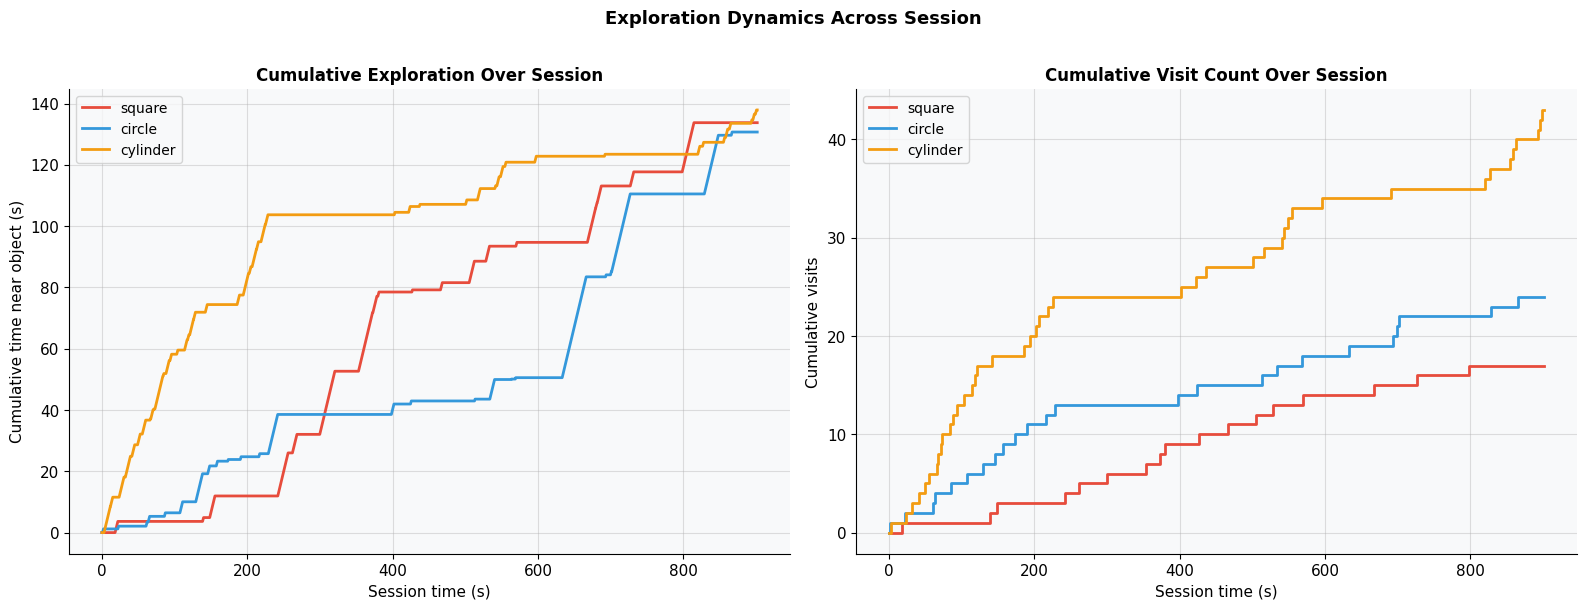

In [58]:
# ─────────────────────────────────────────────────────────────
# Cumulative exploration over session time
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Cumulative duration ──
ax = axes[0]
time_bins = np.linspace(0, DURATION, 200)

for _, row in obj_df.iterrows():
    obj = row['object']
    near_col = f'near_{obj}'
    color = COLORS_OBJ[obj]
    short = obj.split('_', 2)[-1]

    # Cumulative seconds spent near object
    cumulative = np.cumsum(dlc[near_col].values) / FPS
    ax.plot(dlc['time'], cumulative, color=color, linewidth=2, label=short)

ax.set_xlabel('Session time (s)', fontsize=11)
ax.set_ylabel('Cumulative time near object (s)', fontsize=11)
ax.set_title('Cumulative Exploration Over Session', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# ── Cumulative bout count ──
ax = axes[1]
for _, row in obj_df.iterrows():
    obj = row['object']
    color = COLORS_OBJ[obj]
    short = obj.split('_', 2)[-1]

    obj_bouts = bouts_df[bouts_df['object'] == obj].sort_values('start_time')
    if len(obj_bouts) > 0:
        t_points  = [0] + list(obj_bouts['start_time']) + [DURATION]
        n_points  = [0] + list(range(1, len(obj_bouts)+1)) + [len(obj_bouts)]
        ax.step(t_points, n_points, where='post', color=color, linewidth=2, label=short)

ax.set_xlabel('Session time (s)', fontsize=11)
ax.set_ylabel('Cumulative visits', fontsize=11)
ax.set_title('Cumulative Visit Count Over Session', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle('Exploration Dynamics Across Session', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 🎯 Exercise : Latency to First Visit

### Background

**Latency to first contact** is another standard NOR metric:  
how many seconds into the session did the animal first approach each object?

This tells you about initial anxiety vs. curiosity — a bold animal will investigate quickly,  
a timid one will stay near the walls and take longer to approach.

### Your Task

1. Find the **start time of the first bout** for each object  
2. Create a **bar chart** showing first-visit latency per object  
3. Which object was explored first?


In [ ]:
# =============================================================================
# EXERCISE 3: Latency to first visit
# =============================================================================

def compute_first_visit_latency(bouts_df, obj_df):
    """
    Compute the time (in seconds) from session start to the first
    interaction bout for each object.

    Parameters
    ----------
    bouts_df : pd.DataFrame   Output of detect_bouts pipeline
    obj_df   : pd.DataFrame   Object info

    Returns
    -------
    latency_df : pd.DataFrame  Columns: object, first_visit_time_s
    """
    rows = []
    for _, row in obj_df.iterrows():
        obj = row['object']
        obj_bouts = bouts_df[bouts_df['object'] == obj]

        # TODO: Find the start time of the first bout for this object
        # HINT: .sort_values('start_time') then .iloc[0]
        # HINT: If no bouts, use np.nan

        # YOUR CODE HERE
        first_visit = np.nan  # placeholder

        rows.append({'object': obj, 'first_visit_time_s': first_visit})

    return pd.DataFrame(rows)


latency_df = compute_first_visit_latency(bouts_df, obj_df)

# TODO: Plot the latency as a bar chart
# HINT: Use latency_df['object'] for x-axis, 'first_visit_time_s' for y
# HINT: Lower = faster = more exploratory

# YOUR CODE HERE
print("Latency DataFrame:")
print(latency_df)


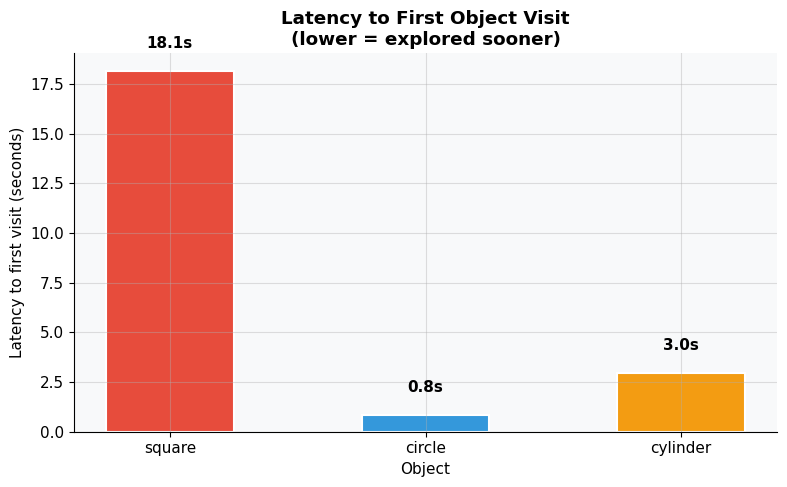

In [ ]:
# =============================================================================
# SOLUTION — Exercise 3
# =============================================================================
# Uncomment to reveal:

# def compute_first_visit_latency(bouts_df, obj_df):
#     rows = []
#     for _, row in obj_df.iterrows():
#         obj = row['object']
#         obj_bouts = bouts_df[bouts_df['object'] == obj].sort_values('start_time')
#         first_visit = obj_bouts.iloc[0]['start_time'] if len(obj_bouts) > 0 else np.nan
#         rows.append({'object': obj, 'first_visit_time_s': first_visit})
#     return pd.DataFrame(rows)

# latency_df = compute_first_visit_latency(bouts_df, obj_df)
# short_names = [o.split('_', 2)[-1] for o in latency_df['object']]
# colors_list = [COLORS_OBJ[o] for o in latency_df['object']]

# fig, ax = plt.subplots(figsize=(8, 5))
# bars = ax.bar(short_names, latency_df['first_visit_time_s'],
#               color=colors_list, edgecolor='white', linewidth=1.5, width=0.5)
# for bar, val in zip(bars, latency_df['first_visit_time_s']):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
#             f'{val:.1f}s', ha='center', va='bottom', fontweight='bold')
# ax.set_ylabel('Latency to first visit (seconds)')
# ax.set_xlabel('Object')
# ax.set_title('Latency to First Object Visit\n(lower = explored sooner)', fontweight='bold')
# plt.tight_layout()
# plt.show()
# print("\nFirst visited:", latency_df.sort_values('first_visit_time_s').iloc[0]['object'])


---
## Part 8: Summary Dashboard

Let's combine everything into a single summary figure — the kind you would include in a paper.


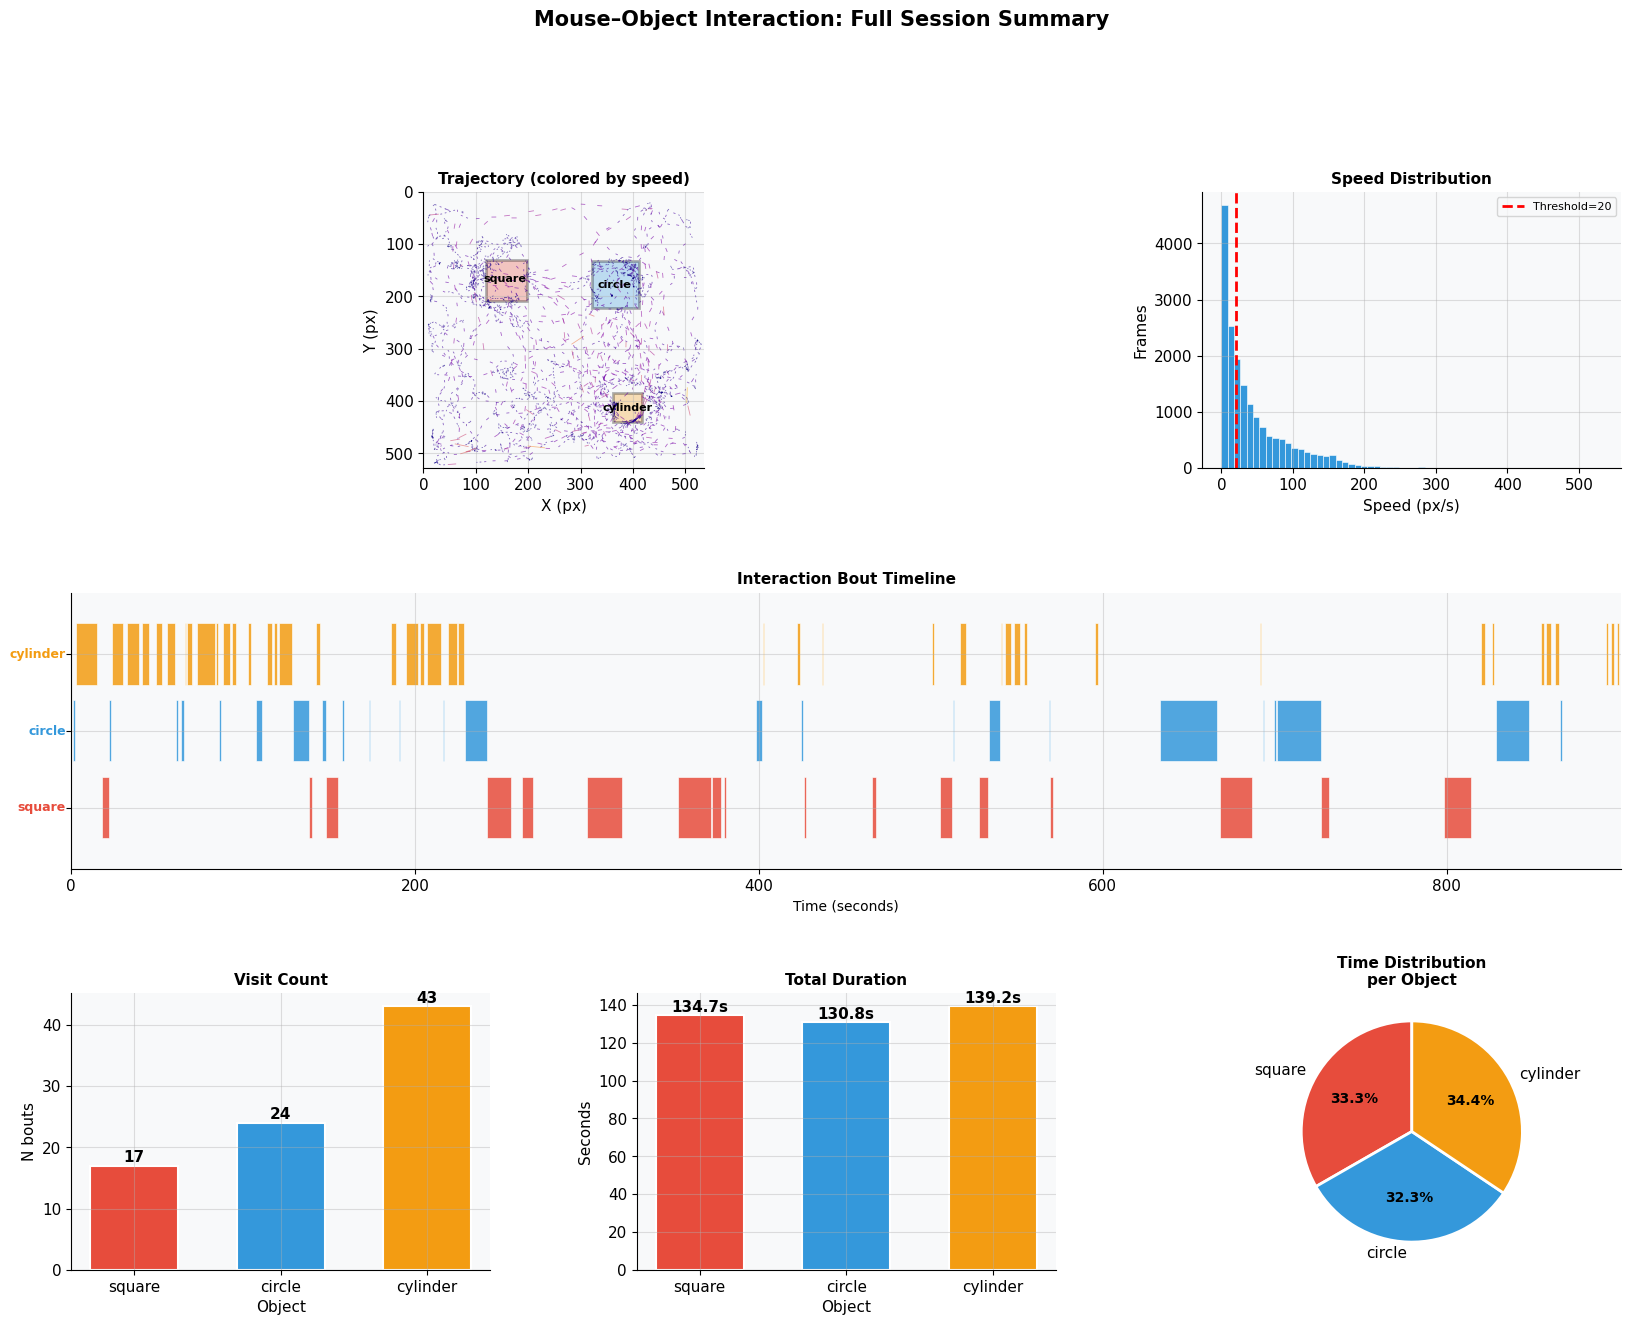

In [61]:
# ─────────────────────────────────────────────────────────────
# Full-session summary dashboard
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (0,0–1): Trajectory ──
ax_traj = fig.add_subplot(gs[0, 0:2])
speed_norm = (dlc['speed'] - dlc['speed'].min()) / (dlc['speed'].max() - dlc['speed'].min() + 1e-9)
for t in range(0, len(dlc)-1, 5):
    ax_traj.plot(dlc['nose_x'].iloc[t:t+2], dlc['nose_y'].iloc[t:t+2],
                 color=plt.cm.plasma(speed_norm.iloc[t]), linewidth=0.6, alpha=0.6)
for _, row in obj_df.iterrows():
    w = row['bbox_x2'] - row['bbox_x1']
    h = row['bbox_y2'] - row['bbox_y1']
    rect = plt.Rectangle((row['bbox_x1'], row['bbox_y1']), w, h, linewidth=2,
                          edgecolor='black', facecolor=COLORS_OBJ[row['object']], alpha=0.3)
    ax_traj.add_patch(rect)
    ax_traj.text(row['center_x'], row['center_y'], row['object'].split('_')[-1],
                 ha='center', va='center', fontsize=8, fontweight='bold')
ax_traj.set_xlim(0, ARENA_W); ax_traj.set_ylim(ARENA_H, 0)
ax_traj.set_title('Trajectory (colored by speed)', fontsize=11, fontweight='bold')
ax_traj.set_aspect('equal'); ax_traj.set_xlabel('X (px)'); ax_traj.set_ylabel('Y (px)')

# ── (0,2): Speed distribution ──
ax_spd = fig.add_subplot(gs[0, 2])
ax_spd.hist(dlc['speed'], bins=60, color='#3498db', edgecolor='white', linewidth=0.4)
ax_spd.axvline(SPEED_THRESHOLD, color='red', linestyle='--', linewidth=2,
               label=f'Threshold={SPEED_THRESHOLD}')
ax_spd.set_xlabel('Speed (px/s)'); ax_spd.set_ylabel('Frames')
ax_spd.set_title('Speed Distribution', fontsize=11, fontweight='bold')
ax_spd.legend(fontsize=8)

# ── (1,0–2): Bout raster ──
ax_raster = fig.add_subplot(gs[1, :])
for i, (_, row) in enumerate(obj_df.iterrows()):
    obj = row['object']
    color = COLORS_OBJ[obj]
    obj_bouts = bouts_df[bouts_df['object'] == obj]
    xranges = [(r['start_time'], r['duration_s']) for _, r in obj_bouts.iterrows()]
    if xranges:
        ax_raster.broken_barh(xranges, (i - 0.4, 0.8),
                              facecolors=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax_raster.text(-3, i, obj.split('_', 2)[-1], ha='right', va='center',
                   color=color, fontsize=9, fontweight='bold')
ax_raster.set_yticks(range(len(obj_df))); ax_raster.set_yticklabels([])
ax_raster.set_xlim(0, DURATION)
ax_raster.set_ylim(-0.8, len(obj_df) - 0.2)
ax_raster.set_xlabel('Time (seconds)', fontsize=10)
ax_raster.set_title('Interaction Bout Timeline', fontsize=11, fontweight='bold')

# ── (2,0): Bout count ──
ax_n = fig.add_subplot(gs[2, 0])
bars = ax_n.bar(short_names, summary_df['n_bouts'],
                color=colors_list, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, summary_df['n_bouts']):
    ax_n.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
              str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax_n.set_title('Visit Count', fontsize=11, fontweight='bold')
ax_n.set_ylabel('N bouts'); ax_n.set_xlabel('Object')

# ── (2,1): Total duration ──
ax_dur = fig.add_subplot(gs[2, 1])
bars = ax_dur.bar(short_names, summary_df['total_duration_s'],
                  color=colors_list, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, summary_df['total_duration_s']):
    ax_dur.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax_dur.set_title('Total Duration', fontsize=11, fontweight='bold')
ax_dur.set_ylabel('Seconds'); ax_dur.set_xlabel('Object')

# ── (2,2): % session time ──
ax_pct = fig.add_subplot(gs[2, 2])
wedges, texts, autotexts = ax_pct.pie(
    summary_df['total_duration_s'],
    labels=[o.split('_', 2)[-1] for o in summary_df['object']],
    colors=colors_list,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
ax_pct.set_title('Time Distribution\nper Object', fontsize=11, fontweight='bold')

plt.suptitle('Mouse–Object Interaction: Full Session Summary',
             fontsize=15, fontweight='bold', y=1.01)
plt.show()


---
## 📋 Summary & Key Takeaways

### Pipeline recap

```
Raw DLC CSV  
    │  
    ├─ Quality control (likelihood threshold + gap interpolation)  
    ├─ Smoothing (Gaussian moving average)  
    │  
    ├─ Feature extraction  
    │      ├─ Speed (px/s)  
    │      ├─ Heading angle (arctan2)  
    │      ├─ Distance from arena center  
    │      └─ Body length (posture)  
    │  
    ├─ Proximity to objects (Euclidean distance < threshold)  
    │  
    ├─ Bout detection (merge short gaps, filter short bouts)  
    │  
    └─ Quantification  
           ├─ Visit count (n_bouts)  
           ├─ Total duration  
           ├─ Mean bout duration  
           ├─ Latency to first visit  
           └─ Discrimination Index (DI)
```

### Key concepts

| Concept | Key point |
|---------|-----------|
| Likelihood filtering | Remove frames where DLC is uncertain — use NaN + interpolation |
| Speed threshold | ~20 px/s cleanly separates resting from locomotion |
| Interaction threshold | ~1.5× object half-diagonal is a good starting point; validate visually |
| Bout merging | Essential to avoid counting one visit as many separate bouts |
| Discrimination Index | Normalized preference metric, robust to total session time |

### Common mistakes to avoid
- ❌ Forgetting to flip the y-axis when plotting (DLC uses top-left origin)
- ❌ Using raw (unfiltered) coordinates for speed — noisy data → artifactual speed spikes
- ❌ Forgetting unit consistency — always note whether values are pixels or cm
- ❌ Using too-small interaction threshold → misses real interactions

---

## 🏠 Homework / Extension

1. **Calibration**: If you have a known ruler in your video, convert pixel measurements to cm.  
   What is the mouse's speed in cm/s?

2. **Multi-animal**: If two mice are present, how would you modify the pipeline to track  
   social interaction (mouse-to-mouse distance)?

3. **Novelty index**: In a novel object recognition task (familiar + novel object),  
   compute the discrimination index and interpret it biologically.

4. **Challenge**: Plot a **heatmap of where interactions occur** in arena space  
   (i.e., is the mouse interacting while approaching the object, or directly at it?).
